# Trabajo Práctico 0 / TS0 | Romero Marchione, Luz | 19/8/26

El siguiente informe contiene la implementación y el análisis de un generador de señales sinusoidales. La función desarrollada permite modificar parámetros como amplitud, valor medio, frecuencia, fase, cantidad de muestras y frecuencia de muestreo.

A partir de esta función se analizará el efecto del muestreo para distintas frecuencias, comparando los resultados obtenidos con lo esperado teóricamente.

## Fundamentos teóricos

La señal sinusoidal utilizada se define como:

$$
x[n] = V_{max}\sin(2\pi f\,t[n] + \phi) + DC
$$
$$
t[n] = \frac{n}{f_s}
$$

Donde:

- $V_{max}$: amplitud máxima de la componente senoidal $[V]$.
- $DC$: valor medio o desplazamiento vertical de la señal $[V]$.
- $f$: frecuencia de la senoidal $[Hz]$.
- $\phi$: fase inicial $[rad]$.
- $f_s$: frecuencia de muestreo $[Hz]$.
- $n$: índice de muestra, con $n = 0,1,\ldots,N-1$.
- $t[n]$: instante temporal correspondiente a cada muestra $[s]$.
- $N$: cantidad total de muestras.

Para analizar el muestreo se utilizará el **criterio de Nyquist**, que establece que la frecuencia de muestreo debe ser mayor al doble de la frecuencia máxima presente en la señal:

$$
f_s > 2f_{max}
$$

De forma equivalente, para una frecuencia de muestreo determinada, la máxima frecuencia que puede representarse sin ambigüedad es:

$$
f_N = \frac{f_s}{2}
$$

donde $f_N$ se denomina **frecuencia de Nyquist**. Este criterio será utilizado luego para analizar qué ocurre al trabajar cerca o por encima de dicho límite.

## Código general

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros de muestreo
fs = 1000  # Frecuencia de muestreo [Hz]
N = 1000   # Cantidad de muestras

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    
    # Índices de las muestras: 0, 1, ..., nn-1
    n = np.arange(0, nn, 1)
    
    # Instantes temporales correspondientes a cada muestra [s]
    tt = n / fs
    
    # Señal senoidal muestreada
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    
    return tt, xx

### Verificación del generador

Para verificar el funcionamiento de la función se genera inicialmente una señal sinusoidal de 10 Hz, con amplitud de 1 V, valor medio nulo y fase inicial nula.

Como se utiliza una frecuencia de muestreo de $f_s=1000$ Hz y se toman $N=1000$ muestras, el intervalo de observación es aproximadamente de 1 segundo. Por lo tanto, para una señal de 10 Hz se esperan observar 10 ciclos completos.

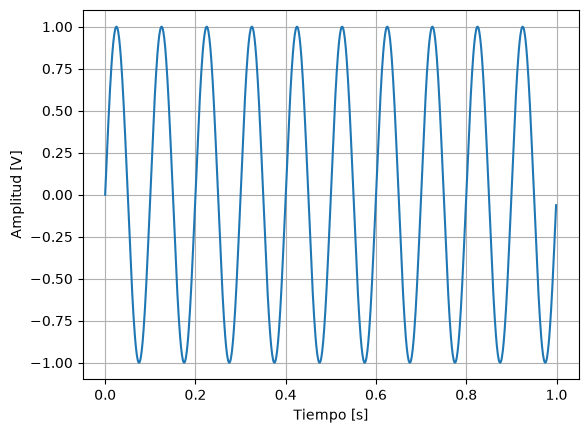

In [37]:
###Prueba de 10Hz
vmax = 1
dc = 0
ff = 10
ph = 0

tt, xx = mi_funcion_sen(vmax=vmax, dc=dc,ff=ff,ph=ph,nn=N, fs=fs)

plt.plot(tt, xx) #Grafica
plt.xlabel('Tiempo [s]') #Agrega título al eje horizontal
plt.ylabel('Amplitud [V]')#Agrega título al eje vertical
plt.grid() #Genera una grilla
plt.show() #Grafica

En el gráfico se observan 10 ciclos completos durante aproximadamente 1 segundo, coincidiendo con lo esperado teóricamente.

## Variación de frecuencias

### Análisis alrededor de la frecuencia de Nyquist

Para visualizar mejor lo que pasa cerca de Nyquist, se grafica la misma senoidal con un paso temporal más chico y, sobre ella, las muestras obtenidas con $f_s = 1000$ Hz.

Como hay $N = 1000$ muestras y juntas se superponen demasiado, en algunos casos se muestran solo las primeras 12 para poder distinguir mejor su comportamiento.

### Muestreo para $f = 500$ Hz

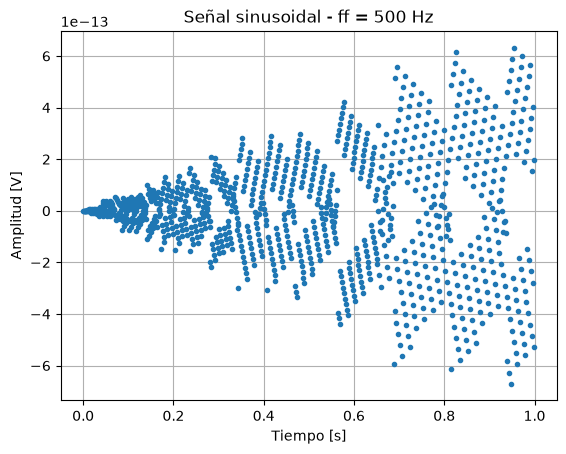

In [38]:
ff = 500

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)

plt.plot(tt, xx, '.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal - ff = 500 Hz')
plt.grid()
plt.show()

Para $f_s = 1000$ Hz, la frecuencia de Nyquist es $f_N = f_s/2 = 500$ Hz, por lo que este caso corresponde al límite crítico del criterio de Nyquist. Al tener exactamente dos muestras por período, para los parámetros elegidos las muestras coinciden con los cruces por cero de la senoidal, por lo que teóricamente se obtiene una señal muestreada nula.

En la simulación aparecen valores del orden de $10^{-13}$ debido a errores numéricos de punto flotante. Matplotlib amplía automáticamente esa escala, pero en la práctica corresponden a cero. Por lo tanto, lo obtenido coincide con lo esperado y muestra que no conviene trabajar justo en el límite $f_s = 2f$ ya que a partir de las muestras podríamos interpretar que la señal original era nula cuando en realidad no lo era.

### Muestreo para $f = 499$ Hz

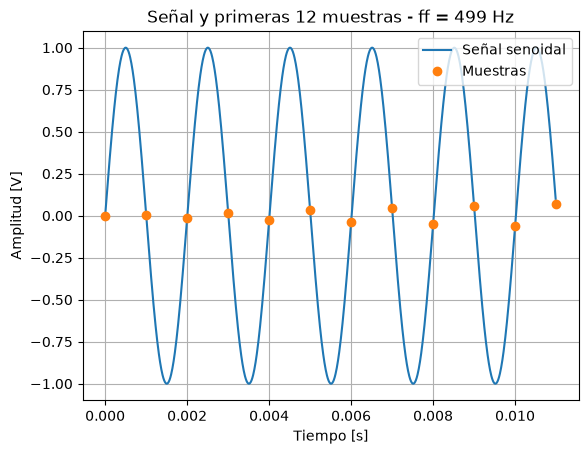

In [39]:
ff = 499
vmax = 1
dc = 0
ph = 0

# Muestras del ADC
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# Señal senoidal con más puntos para visualizar la curva
t_cont = np.arange(0, tt[11], 0.00001)
x_cont = vmax * np.sin(2*np.pi*ff*t_cont + ph) + dc

# Gráfico de la señal y las muestras
plt.plot(t_cont, x_cont, label='Señal senoidal')
plt.plot(tt[:12], xx[:12], 'o', label='Muestras')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal y primeras 12 muestras - ff = 499 Hz')
plt.grid()
plt.legend(loc='upper right')
plt.show()

### Muestreo para $f = 50$ Hz

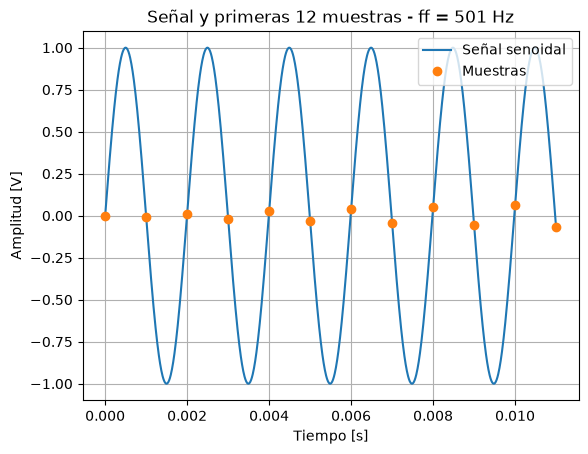

In [40]:
ff = 501
vmax = 1
dc = 0
ph = 0

# Muestras del ADC
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# Señal senoidal con más puntos para visualizar la curva
t_cont = np.arange(0, tt[11], 0.00001)
x_cont = vmax * np.sin(2*np.pi*ff*t_cont + ph) + dc

# Gráfico de la señal y las muestras
plt.plot(t_cont, x_cont, label='Señal senoidal')
plt.plot(tt[:12], xx[:12], 'o', label='Muestras')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal y primeras 12 muestras - ff = 501 Hz')
plt.grid()
plt.legend(loc='upper right')
plt.show()

### Comparación entre $f = 499$ Hz y $f = 501$ Hz

Con $f_s = 1000$ Hz, la frecuencia de Nyquist es $500$ Hz. La señal de $499$ Hz queda dentro del rango sin ambigüedad, mientras que la de $501$ Hz supera este límite.

Al comparar las muestras se observa que tienen igual magnitud pero signo opuesto:

$$
x_{501}[n] = -x_{499}[n]
$$

Esto se debe a que ambas frecuencias están a la misma distancia de Nyquist, una por debajo y otra por encima. Al superar los 500 Hz, la señal de 501 Hz ya no puede identificarse de forma única a partir de sus muestras y queda asociada a la de 499 Hz, pero con signo opuesto. Este efecto se denomina aliasing: distintas señales originales pueden producir muestras que generan una ambigüedad sobre cuál era realmente la señal de entrada.

Justamente, el criterio $f_s > 2f_{max}$ busca evitar esta pérdida de información.

### Muestreo para $f = 999$ Hz

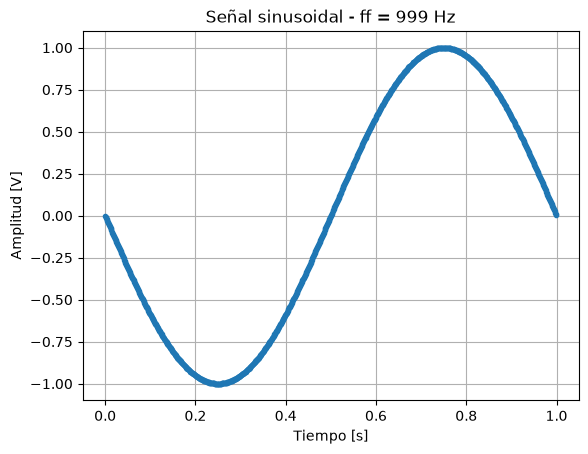

In [41]:
ff = 999

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)

plt.plot(tt, xx, '.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal - ff = 999 Hz')
plt.grid()
plt.show()

### Muestreo para $f = 1001$ Hz

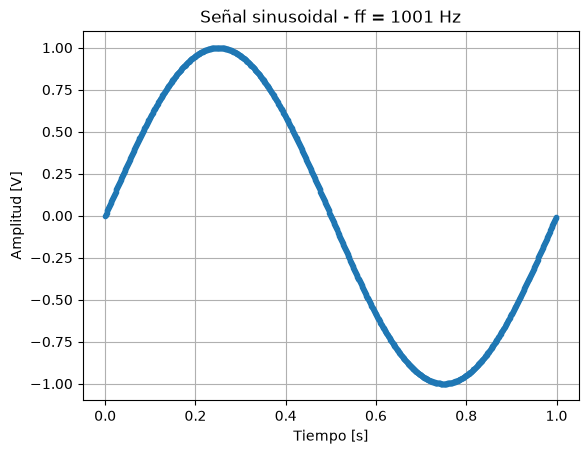

In [42]:
ff = 1001

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)

plt.plot(tt, xx, '.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal - ff = 1001 Hz')
plt.grid()
plt.show()

### Muestreo para $f = 2001$ Hz

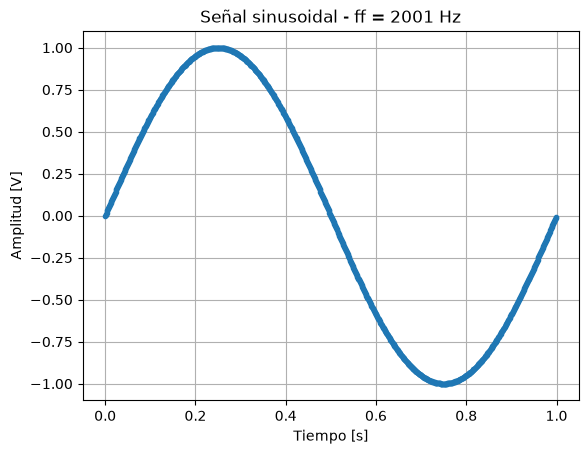

In [43]:
ff = 2001

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)

plt.plot(tt, xx, '.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal - ff = 2001 Hz')
plt.grid()
plt.show()

### Análisis para $f = 999$ Hz, $f = 1001$ Hz y $f = 2001$ Hz

En los gráficos se observa que las señales muestreadas para $999$ Hz y $1001$ Hz tienen una variación equivalente a una frecuencia de $1$ Hz, aunque con signo opuesto, mientras que para $2001$ Hz se obtiene nuevamente el mismo comportamiento que para $1$ Hz.

Esto ocurre porque, una vez que la señal es muestreada con $f_s = 1000$ Hz, sumar o restar múltiplos de 1000 Hz no cambia necesariamente los valores obtenidos en los instantes de muestreo. La idea es análoga a lo que ocurre con una función seno al sumar una vuelta completa, es decir $2\pi$ rad, ya que $\sin(\theta + 2\pi k)=\sin(\theta)$ para $k$ entero.

Teniendo en cuenta esto, 1001 Hz puede pensarse como 1000+1 Hz: el término de 1000 Hz representa una vuelta completa entre muestras, por lo que queda el mismo comportamiento que para 1 Hz. Para 2001 Hz ocurre lo mismo, pero con dos vueltas completas. Por lo tanto:

$$
x_1[n] = x_{1001}[n] = x_{2001}[n]
$$

Para 999 Hz puede pensarse como 1000-1 Hz, por lo que queda un comportamiento equivalente a -1 Hz. Como la función seno es impar, $\sin(-\theta)=-\sin(\theta)$, las muestras tienen la misma variación que para $1$ Hz pero con signo opuesto:

$$
x_{999}[n] = -x_1[n]
$$

Por lo tanto, frecuencias analógicas distintas pueden generar los mismos valores al ser muestreadas, ya que las vueltas completas que ocurren entre muestras no pueden distinguirse a partir de los puntos obtenidos.